## Section 2.3: Independent Variables and Random Samples

**Topics:** Joint probability distributions, Correlation and dependence, Random samples

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1zvxRaxXHQviQOddXOkOFiNoWjIMspK_V?usp=sharing)

In [45]:
# Import Necessary Packages
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Formatting and Spacing:
np.set_printoptions(formatter={'int': str})

## Section 2.3.1: Joint probability distributions

Joint probability distributions show probability distributions for at least two or more variables. The function is defined by a pair of numbers (x,y), such that the function p(x,y) = P(X = x and Y = y).

In this example, we show how a joint probability distribution may be measured using an array of joint probabilities, x_values, and y_values.


In [46]:
# Setup Joint Probabilties, x_values, and y_values
joint = np.array([[0.22, 0.38, 0.23],
                  [0.05, 0.02, 0.10]])
x_values = np.array([0, 1])
y_values = np.array([0, 1, 2])
# Set up P(x), P(y), and calculate joint probability.
px = joint.sum(axis=1)
py = joint.sum(axis=0)
print("Cumulative: joint total =", joint.sum())
print("What is P(X)?", px)
print("What is P(Y)?", py)
print("P(Y=2 | X=1) =", joint[1, 2] / px[1])


Cumulative: joint total = 1.0
What is P(X)? [0.83 0.17]
What is P(Y)? [0.27 0.4  0.33]
P(Y=2 | X=1) = 0.5882352941176471


This is what a graphical representation looks like between P(Y=2 | X=1) on a heatmap.

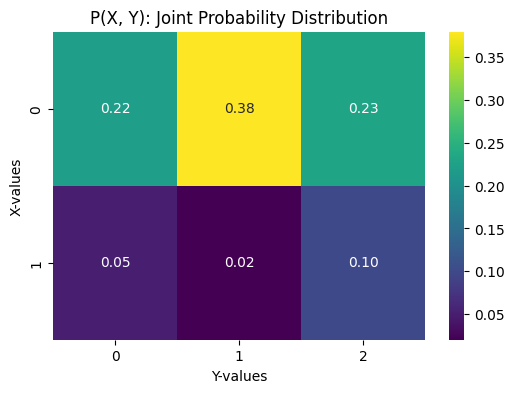

In [47]:
# Plot x and y values on a heat map.
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(joint, annot=True, fmt=".2f", cmap="viridis", xticklabels=y_values, yticklabels=x_values, ax=ax)
ax.set_xlabel('Y-values')
ax.set_ylabel('X-values')
ax.set_title('P(X, Y): Joint Probability Distribution')
plt.show()

## 2.3.2 Correlation and Dependence:

Correlation analyzes practical relationships between random variables, helping us understand whether two random variables are independent (non-correlated) or dependent (correlated). In this example, we demonstrate how random variables are measured for dependence based on strength of correlation.

corr(x, dependent y) = 0.9653474789541454
corr(x, independent y) = 0.04649827593297137


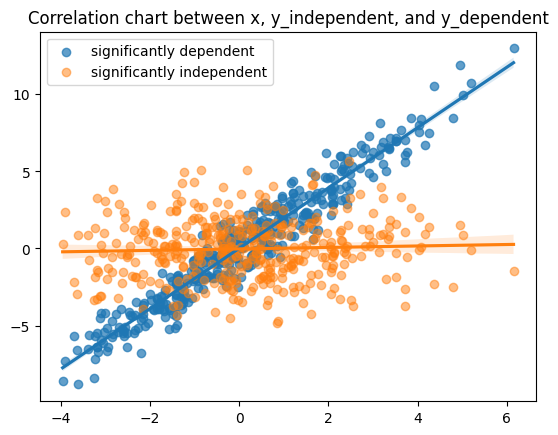

In [48]:
# Randomizee values here for x, y_dependent, and y_independent.
rng = np.random.default_rng()
x = rng.normal(0, 2, 400)
y_dependent = 2 * x + rng.normal(0, 1, 400)
y_independent = rng.normal(0, 2, 400)

# Print out correlation values between x and dependent_y, and x and independent_y to analyze correlation.
print("corr(x, dependent y) =", np.corrcoef(x, y_dependent)[0, 1])
print("corr(x, independent y) =", np.corrcoef(x, y_independent)[0, 1])
# Plot linear correlation here.
sns.regplot(x=x, y=y_dependent, scatter_kws={'alpha':0.7}, label="significantly dependent", ci=95)
sns.regplot(x=x, y=y_independent, scatter_kws={'alpha':0.5}, label="significantly independent", ci=95)
plt.legend()
plt.title("Correlation chart between x, y_independent, and y_dependent")
plt.show()

Notice a few things.
For the blue line, its absolute value of the correlation value close to 1 signaling a dependent relationship. For the orange line, an absolute value of the correlation value close to 0 signals high confidence in an independent relationship.

## 2.3.3: Random samples

Random samples are randomly selected subsets of the population where each member has a known chance of being selected to participate. Some subcategories of samples like these include a simple random sample, where each member is equally likely to be selected.

In this example, we use around 128K number of simulations with a randomized sample to measure the sample mean and standard deviation. Then, we graphically represent what the sampling distribution may look like for the sample mean.

SAMPLE MEAN ANALYSIS
Expected value E(X) of sample means = 2.0000126077400906
Variance V(X) of sample means = 0.13388911843058984
Stdev of sample means = 0.36590862032834076
Total number of samples = 128000


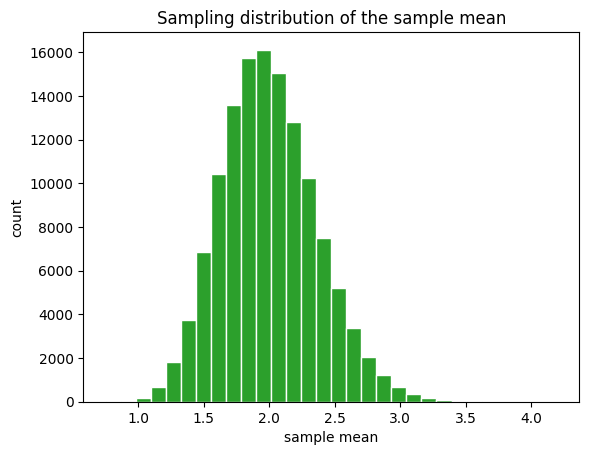

In [49]:
sample_means = []
rng = np.random.default_rng()
num_simulations = 128000
for _ in range(num_simulations):
    sample = rng.exponential(scale=2.0, size=30)
    sample_means.append(sample.mean())

sample_means = np.array(sample_means)
print("SAMPLE MEAN ANALYSIS")
print("Expected value E(X) of sample means =", sample_means.mean())
print("Variance V(X) of sample means =", sample_means.var())
print("Stdev of sample means =", sample_means.std())
print("Total number of samples =", len(sample_means))


plt.hist(sample_means, bins=30, color="tab:green", edgecolor="white")
plt.title("Sampling distribution of the sample mean")
plt.xlabel("sample mean")
plt.ylabel("count")
plt.show()